# Quiz 4 - Redes Neuronales

In [1]:
import numpy as np

In [2]:
def find_initial_boundaries(index,w,x,target, NN = lambda x, w: np.dot(x, w)):
    w_low = w.copy()
    w_high = w.copy()
    w_low[index] = -1
    w_high[index] = 1
    out_low = NN(x, w_low)
    out_high = NN(x, w_high)
    while not (out_low < target < out_high or out_high < target < out_low):
        if out_low > target:
            w_low[index] *=2
        if out_high < target:
            w_high[index] *= 2
        out_low = NN(x, w_low)
        out_high = NN(x, w_high)
    return w_low[index], w_high[index]

def find_weight(index,w,x,target, NN = lambda x, w: np.dot(x, w)):
    w_i_low, w_i_high = find_initial_boundaries(index, w, x, target, NN=NN)
    w_low = w.copy()
    w_high = w.copy()
    w_low[index] = w_i_low
    w_high[index] = w_i_high
    out_low = NN(x, w_low)
    out_high = NN(x, w_high)
    while abs(out_high - out_low) > 1e-8:
        w_mid = (w_low + w_high) / 2
        out_mid = NN(x, w_mid)
        if out_mid < target:
            w_low = w_mid
            out_low = out_mid
        else:
            w_high = w_mid
            out_high = out_mid
    r = (w_low + w_high) / 2
    return r[index]

Considere la siguiente red neuronal:

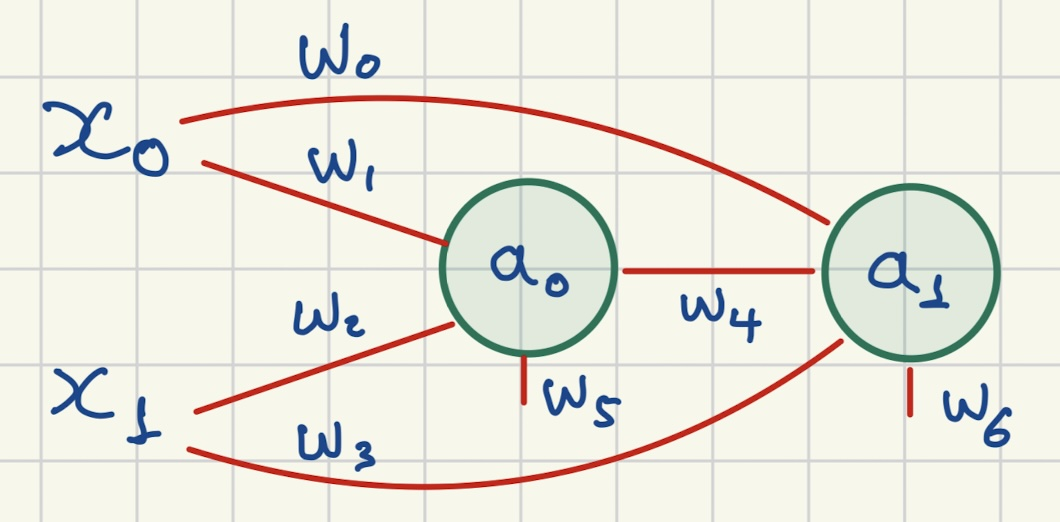

La función de activación de las neuronas a0 y a1 es sigmoide.

La red neuronal tiene los siguiente parámetros vector de pesos $w = (w_0, -0,59, 0,34, -1,96, -0,69, -1,17, 0,47)$

¿Qué valor debe tener $w_0$ de tal forma que la salida de la red neuronal sea exactamente $0,41$ si la entrada es $(0.5, 0.5)$?

Responda con tres cifras decimales.

Recuerde que la función sigmoide se define como:

sigmoide(x) = $\frac{1}{1 + e^{-x}}$

In [3]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))
relu = lambda x: np.maximum(0, x)

def NN(x,w):
    z0 = x @ w[1:3] + w[5]
    a0 = sigmoid(z0)
    z1 = a0 * w[4] + x @ np.array([w[0],w[3]]) + w[6]
    a1 = sigmoid(z1)
    return a1

In [4]:
w = np.array([
    0,
    -0.59,
    0.34,
    -1.96,
    -0.69,
    -1.17,
    0.47
])

x = np.array([
    0.5,
    0.5
])

target = 0.41
index = 0

In [5]:
weight = find_weight(index, w, x, target, NN=NN)
w_finals = w.copy()
w_finals[index] = weight
print(f"Weight for w[{index}]: {weight:.8f}")
print(f"Output with final weights: {NN(x, w_finals):.8f}")
assert abs(NN(x, w_finals) - target) < 1e-8, "Output does not match target"

Weight for w[0]: 0.58877990
Output with final weights: 0.41000000
